#### 1. IMPORTS & CONFIG

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import copy

TARGET_ORDER = ['None_Existent', 'Low', 'Medium', 'High', 'Very_High']

# Configuration
CONFIG = {
    "seed": 80085,
    "n_folds": 5,
    "batch_size": 64,
    "epochs": 50,
    "learning_rate": 1e-3,
    "patience": 10,  # For early stopping
    "hidden_layers": [256, 128, 64],
    "dropout": 0.3
}

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(CONFIG["seed"])


Using device: cpu


#### 2. LOAD DATA

In [2]:
# Load Data
train_df = pd.read_csv('../data/training_data_hybrid.csv')
test_df = pd.read_csv('../data/test_data_hybrid.csv')
y_train = pd.read_csv('../data/y_train_hybrid.csv')

# TO DO
# Merge features and target for easier handling (optional, but helps keep track)
# We will keep them separate arrays for the CV loop

# Preprocessing Function
def preprocess_data(train_df, test_df):
    # Drop ID columns if they exist
    if 'RowId' in train_df.columns:
        train_df = train_df.drop(columns=['RowId'])
    if 'RowId' in test_df.columns:
        test_df = test_df.drop(columns=['RowId'])
    
    # Handle Boolean columns (True/False -> 1.0/0.0)
    # Select boolean columns
    bool_cols = train_df.select_dtypes(include=['bool']).columns
    train_df[bool_cols] = train_df[bool_cols].astype(float)
    test_df[bool_cols] = test_df[bool_cols].astype(float)
    
    # Scaling (Standardization is crucial for NNs)
    scaler = StandardScaler()
    
    # Fit on train, transform both
    X_train_scaled = scaler.fit_transform(train_df.values)
    X_test_scaled = scaler.transform(test_df.values)
    
    return X_train_scaled, X_test_scaled

X_all, X_test_final = preprocess_data(train_df, test_df)
y_all = y_train['AVERAGE_SPEED_DIFF'].values

print(f"Input Features: {X_all.shape[1]}")
print(f"Target Classes: {len(np.unique(y_all))}")


Input Features: 22
Target Classes: 5


#### 4. PYTORCH DATASET & MODEL ARCHITECTURE

In [3]:
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y) if y is not None else None
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

class SpeedDiffNN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=[128, 64], dropout=0.3):
        super(SpeedDiffNN, self).__init__()
        
        layers = []
        in_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Stabilize learning
            layers.append(nn.LeakyReLU(0.01))
            layers.append(nn.Dropout(dropout))    # Prevent overfitting
            in_dim = h_dim
            
        layers.append(nn.Linear(in_dim, output_dim))
        
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)


#### 5. TRAINING ENGINE

In [4]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, patience=10):
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    
    train_losses, val_losses = [], []
    
    for epoch in range(CONFIG["epochs"]):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        
        # --- Validation Phase ---
        model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        epoch_acc = accuracy_score(all_labels, all_preds)
        
        # --- Scheduler Step ---
        scheduler.step(epoch_val_loss)
        
        # --- Save Best Model & Early Stopping ---
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0 # Reset patience
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
            
    # Load best weights
    model.load_state_dict(best_model_wts)
    return model, best_acc


#### 6. MAIN EXECUTION: CROSS VALIDATION 5 FOLDS

In [5]:
skf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True, random_state=CONFIG["seed"])

# Placeholders for results
oof_preds = np.zeros((len(X_all), 5)) # 5 Classes
test_preds_accum = np.zeros((len(X_test_final), 5))
fold_accuracies = []

print(f"Starting {CONFIG['n_folds']}-Fold Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    print(f"\n--- FOLD {fold + 1} ---")
    
    # Split Data
    X_train, y_train_fold = X_all[train_idx], y_all[train_idx]
    X_val, y_val_fold = X_all[val_idx], y_all[val_idx]
    
    # Create Datasets & Loaders
    train_dataset = TabularDataset(X_train, y_train_fold)
    val_dataset = TabularDataset(X_val, y_val_fold)
    test_dataset = TabularDataset(X_test_final) # No labels for test
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
    
    # Initialize Model
    model = SpeedDiffNN(input_dim=X_all.shape[1], output_dim=5, 
                        hidden_dims=CONFIG["hidden_layers"], dropout=CONFIG["dropout"])
    model = model.to(device)
    
    # Calculate weights based on inverse frequency
    class_counts = np.bincount(y_all.astype(int))
    total_samples = len(y_all)
    class_weights = torch.FloatTensor(total_samples / (5 * class_counts)).to(device)

    # Manual boosting factors
    manual_boost = torch.tensor([1.0, 1.2, 1.0, 1.2, 1.1]).to(device) 

    final_weights = class_weights * manual_boost
    
    criterion = nn.CrossEntropyLoss(weight=final_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    # Train
    model, best_acc = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, patience=CONFIG["patience"])
    fold_accuracies.append(best_acc)
    print(f"Fold {fold+1} Best Accuracy: {best_acc:.4f}")
    
    # --- Generate Predictions ---
    model.eval()
    
    # 1. OOF Predictions (for blending)
    # Re-create val loader without shuffle to ensure order matches val_idx
    val_loader_pred = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
    fold_probs = []
    with torch.no_grad():
        for inputs, _ in val_loader_pred:
            inputs = inputs.to(device)
            outputs = torch.softmax(model(inputs), dim=1) # Get probabilities
            fold_probs.extend(outputs.cpu().numpy())
    
    oof_preds[val_idx] = np.array(fold_probs)
    
    # 2. Test Predictions (average later)
    fold_test_probs = []
    with torch.no_grad():
        for inputs in test_loader:
            inputs = inputs.to(device)
            outputs = torch.softmax(model(inputs), dim=1)
            fold_test_probs.extend(outputs.cpu().numpy())
            
    test_preds_accum += np.array(fold_test_probs)

print(f"\nMean CV Accuracy: {np.mean(fold_accuracies):.4f}")


Starting 5-Fold Training...

--- FOLD 1 ---
Fold 1 Best Accuracy: 0.7872

--- FOLD 2 ---
Early stopping at epoch 28
Fold 2 Best Accuracy: 0.7968

--- FOLD 3 ---
Early stopping at epoch 26
Fold 3 Best Accuracy: 0.7614

--- FOLD 4 ---
Early stopping at epoch 37
Fold 4 Best Accuracy: 0.7812

--- FOLD 5 ---
Early stopping at epoch 27
Fold 5 Best Accuracy: 0.7746

Mean CV Accuracy: 0.7802


#### 8. FINALIZING AND SAVING FOR BLEND

In [6]:
# Average the test predictions
test_probs_final = test_preds_accum / CONFIG["n_folds"]

# Create DataFrames for saving
# OOF Probabilities (Indices align with original train data)
cols = [f'Class_{i}' for i in range(5)]
oof_df = pd.DataFrame(oof_preds, columns=cols)
# It's often useful to keep the RowId or index to merge safely later
# oof_df['RowId'] = ... (if you want to attach IDs)

# Test Probabilities
test_pred_df = pd.DataFrame(test_probs_final, columns=cols)

# Save to CSV
oof_df.to_csv('../outputs/probs/nn_oof_probs.csv', index=False)
test_pred_df.to_csv('../outputs/probs/nn_test_probs.csv', index=False)

print("Files 'nn_oof_probs.csv' and 'nn_test_probs.csv' saved successfully.")
print("You can now load these into your ensemble notebook.")


Files 'nn_oof_probs.csv' and 'nn_test_probs.csv' saved successfully.
You can now load these into your ensemble notebook.


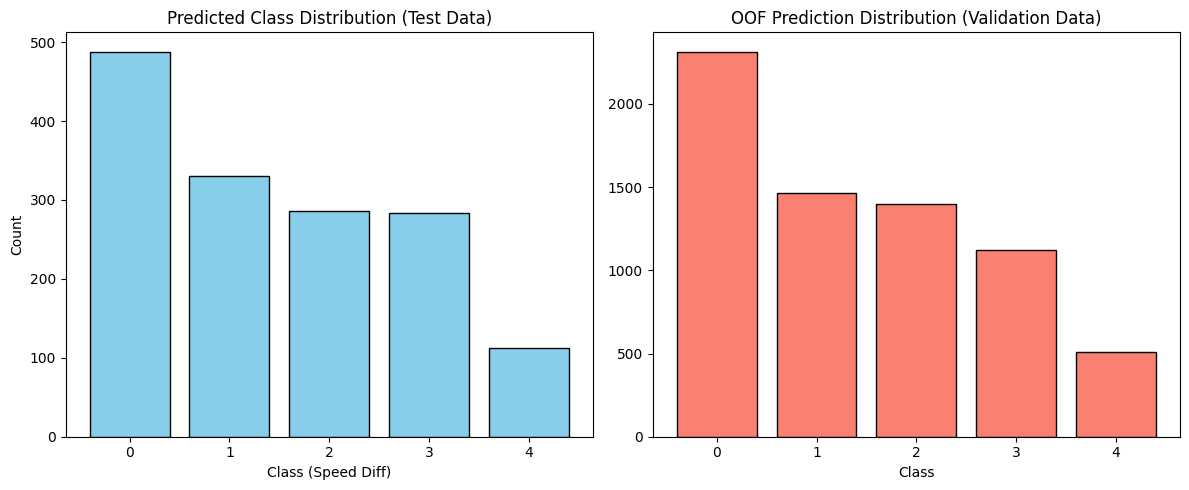

In [7]:
# --- Plot Training History ---
# (Requires that you tracked 'train_losses' and 'val_losses' inside the train loop)
# Since the previous function returned just the model, let's visualize the Predictions instead.

plt.figure(figsize=(12, 5))

# 1. Check Class Distribution of Predictions
plt.subplot(1, 2, 1)
unique, counts = np.unique(np.argmax(test_probs_final, axis=1), return_counts=True)
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.title("Predicted Class Distribution (Test Data)")
plt.xlabel("Class (Speed Diff)")
plt.ylabel("Count")
plt.xticks(range(5))

# 2. Compare with OOF (Validation) Distribution
plt.subplot(1, 2, 2)
unique_oof, counts_oof = np.unique(np.argmax(oof_preds, axis=1), return_counts=True)
plt.bar(unique_oof, counts_oof, color='salmon', edgecolor='black')
plt.title("OOF Prediction Distribution (Validation Data)")
plt.xlabel("Class")
plt.xticks(range(5))

plt.tight_layout()
plt.show()



Overall CV Accuracy: 0.7802
Overall CV Macro F1: 0.7747

Classification Report:
               precision    recall  f1-score   support

None_Existent       0.85      0.90      0.88      2200
          Low       0.66      0.68      0.67      1419
       Medium       0.81      0.69      0.74      1651
         High       0.74      0.78      0.75      1063
    Very_High       0.80      0.85      0.83       479

     accuracy                           0.78      6812
    macro avg       0.77      0.78      0.77      6812
 weighted avg       0.78      0.78      0.78      6812



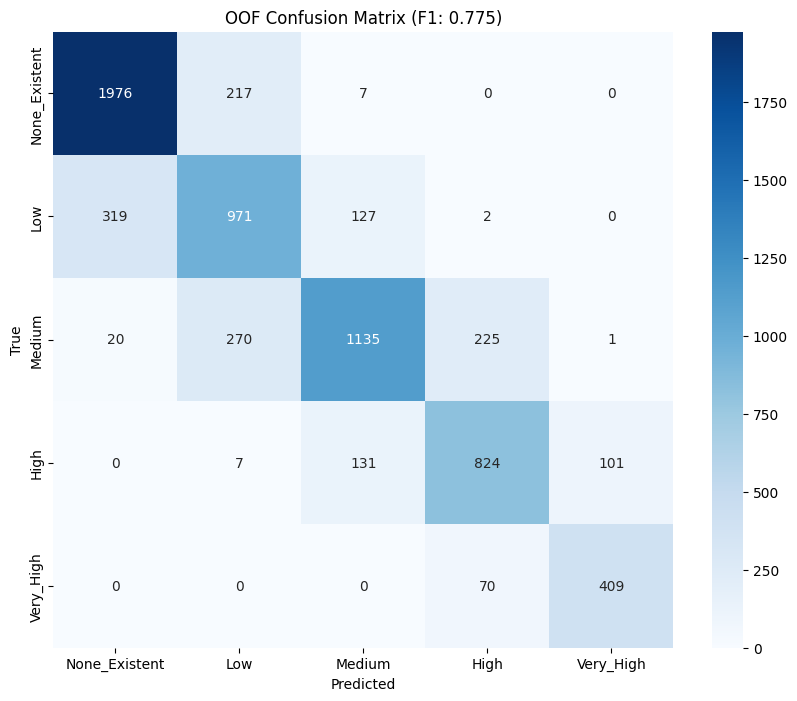

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert probabilities to class labels
oof_preds_labels = np.argmax(oof_preds, axis=1)

# 2. Calculate Overall Metrics
accuracy = accuracy_score(y_all, oof_preds_labels)
f1 = f1_score(y_all, oof_preds_labels, average='macro')

print(f"Overall CV Accuracy: {accuracy:.4f}")
print(f"Overall CV Macro F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_all, oof_preds_labels, target_names=TARGET_ORDER))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_all, oof_preds_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=TARGET_ORDER, yticklabels=TARGET_ORDER)
plt.title(f'OOF Confusion Matrix (F1: {f1:.3f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 4. Plot Loss Curves (Requires slight modification to training loop to return history)
# Since we can't easily go back in time to get the history without retraining,
# we will focus on the confusion matrix which is more actionable right now.


In [9]:
# Load original test file to get the correct RowIds
test_df_orig = pd.read_csv('../data/test_data_hybrid.csv')

# Get the class with the highest probability
final_predictions = np.argmax(test_probs_final, axis=1)

# Decode & Save
pred_labels = [TARGET_ORDER[i] for i in final_predictions]

submission_nn = pd.DataFrame({
    'RowId': test_df_orig['RowId'],
    'Speed_Diff': pd.Series(pred_labels).replace('None_Existent', 'None')
})

# Save submission
submission_nn.to_csv('../outputs/submissions/submission_nn_only.csv', index=False)

print("'submission_nn_v2_only.csv' created successfully!")
print(submission_nn.head())


'submission_nn_v2_only.csv' created successfully!
   RowId Speed_Diff
0      1       None
1      2        Low
2      3       None
3      4       High
4      5        Low
